#  Data Source

###### Load Dependencies

In [1]:
from importlib import reload
import numpy as np
import scalers
from data import *
from sklearn.preprocessing import OneHotEncoder as HotEncoder
from imputers import *
from scalers import StandardScaler, NormalScaler
import data as db
import matplotlib.pyplot as plt
reload( db )
import pandas as pd
import warnings
hdr = '\r\n' + '-' * 120 + '\r\n'
nwln = '\r\n'
warnings.filterwarnings( 'ignore' )

###### Load Data

In [2]:
# Load Data
schedx_filepath = r'C:\Users\terry\source\repos\mathy\stores\excel\Combined Schedules.xlsx'
index_columns = [ 'CombinedSchedulesId', ]
nominal_columns = [ 'MainAccount', 'TreasurySymbol', 'AccountName',
					'LineName', 'Line', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
out_years = [ f'OY-{i}' for i in range( 1, 10 ) ]
numeric_columns = [ 'PY', 'CY' ]
data_columns = [ 'Line'  ]
all_columns = index_columns + nominal_columns + numeric_columns
drop_columns = [ 'LineName', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
max_columns =  data_columns + numeric_columns
dtype_dict = \
{
	'MainAccount': str,
	'TreasurySymbol': str
}

df_excel = pd.read_excel( schedx_filepath, usecols=all_columns, sheet_name='Data'  )
df_excel.reset_index( )
df_excel.round( 2 )
# Fix formatting: pad with leading zeros and split TreasurySymbol
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.replace( 'A-', '', regex=False )
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.zfill( 4 )
df_excel[ 'TreasurySymbol' ] = df_excel[ 'TreasurySymbol' ].str.replace( 'A-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.replace( 'L-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.zfill( 4 )
df_excel[ 'AgencyCode' ] = df_excel[ 'TreasurySymbol' ].str[ :3 ].str.zfill( 3 )
df_excel[ 'MainAccountCode' ] = df_excel[ 'TreasurySymbol' ].str[ 3: ].str.zfill( 4 )
df_excel[ numeric_columns ] = df_excel[ numeric_columns ].round( 2 )
df_dataset = df_excel[ all_columns ].copy( )
df_nominal = df_excel[ nominal_columns ].copy( )
df_numeric = df_excel[ numeric_columns ].copy( )
df_schedx = df_excel[ max_columns ].copy( )
sns.set_style( 'darkgrid' )

In [3]:
# Load Data Source
ds = db.DataSource( df=df_schedx, target='CY' )
cols = ds.categorical_columns
targets = ds.targets
data = ds.dataframe
std_data = ds.standardize( )
ln = ds.encode_labels( 'Line' )
tgt = ds.encode_targets( )
py = data[ 'PY' ].values
cy = data[ 'CY' ].values
lines = pd.Series( ln, name='Line' )
data[ 'Line' ] = lines
data

,Line,PY,CY
0,0,901000000,901000000
1,1,82000000,82000000
2,2,29000000,29000000
3,9,348000000,348000000
4,10,10508000000,12508000000
...,...,...,...
2395,155,1000000,1000000
2396,156,1000000,1000000
2397,203,20000000,20000000
2398,204,18000000,18000000


# Classification Models

In [8]:
import classifications as cs
reload( cs )

<module 'classifications' from 'C:\\Users\\terry\\source\\repos\\Mathy\\classifications.py'>

####  🧠 Perceptron

In [9]:
percetron = cs.Perceptron( )
X = data.values
y = ds.targets
percetron.train( X, y )
percetron.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.4125,0.39375,0.0,0.40875,0.0,0.00486,0.0
1,0.4125,0.39375,0.0,0.40875,0.0,0.00486,0.0
2,0.4125,0.39375,0.0,0.40875,0.0,0.00486,0.0
3,0.4125,0.39375,0.0,0.40875,0.0,0.00486,0.0
4,0.4125,0.39375,0.0,0.40875,0.0,0.00486,0.0
...,...,...,...,...,...,...,...
395,0.4125,0.39375,0.0,0.40875,0.0,0.00486,0.0
396,0.4125,0.39375,0.0,0.40875,0.0,0.00486,0.0
397,0.4125,0.39375,0.0,0.40875,0.0,0.00486,0.0
398,0.4125,0.39375,0.0,0.40875,0.0,0.00486,0.0


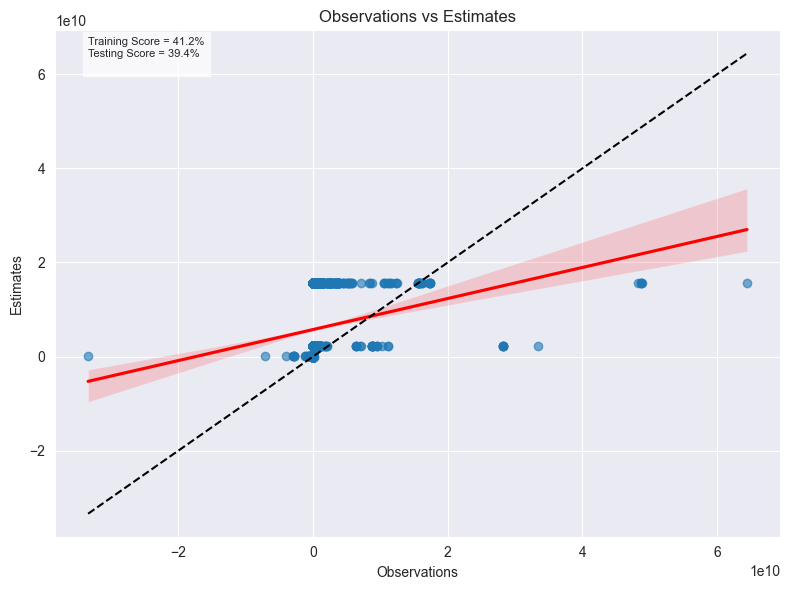

In [10]:
percetron.scatter_plot( X, y )

####  📈 Least Squares

In [11]:
least_squares = cs.LeastSquares( )
X = data.values
y = ds.targets
least_squares.train( X, y )
least_squares.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
1,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
2,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
3,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
4,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
...,...,...,...,...,...,...,...
396,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
397,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
398,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0
399,1.0,1.0,0.0,0.41125,0.0,0.002377,0.0


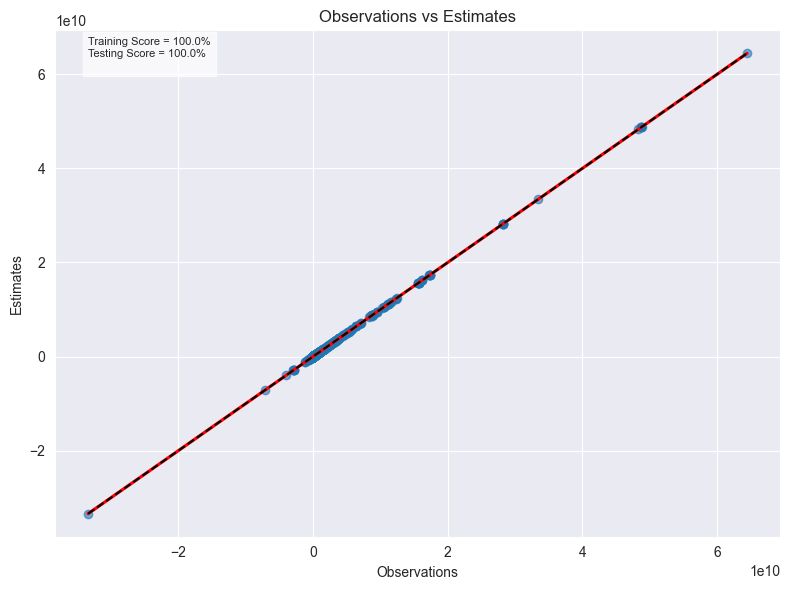

In [12]:
least_squares.scatter_plot( X, y )

####  📉 Logistic Regression

In [13]:
logistic = cs.LogisticRegression( )
X = ds.data
y = ds.targets
logistic.train( X, y )
logistic.score( X, y )


,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.428646,0.402083,0.0,0.4325,0.0,0.0025,0.0
1,0.428646,0.402083,0.0,0.4325,0.0,0.0025,0.0
2,0.428646,0.402083,0.0,0.4325,0.0,0.0025,0.0
3,0.428646,0.402083,0.0,0.4325,0.0,0.0025,0.0
4,0.428646,0.402083,0.0,0.4325,0.0,0.0025,0.0
...,...,...,...,...,...,...,...
396,0.428646,0.402083,0.0,0.4325,0.0,0.0025,0.0
397,0.428646,0.402083,0.0,0.4325,0.0,0.0025,0.0
398,0.428646,0.402083,0.0,0.4325,0.0,0.0025,0.0
399,0.428646,0.402083,0.0,0.4325,0.0,0.0025,0.0


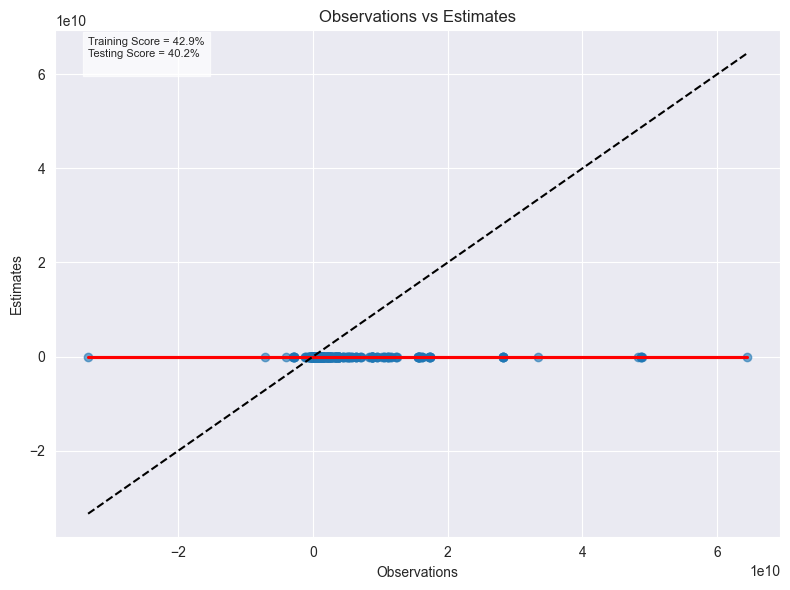

In [14]:
logistic.scatter_plot( X, y )

####  🎯️ LASSO

In [15]:
lasso = cs.Lasso( )
X = data.values
y = ds.targets
lasso.train( X, y )
lasso.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.999991,0.999989,0.0,0.100833,0.0,0.000583,0.0
1,0.999991,0.999989,0.0,0.100833,0.0,0.000583,0.0
2,0.999991,0.999989,0.0,0.100833,0.0,0.000583,0.0
3,0.999991,0.999989,0.0,0.100833,0.0,0.000583,0.0
4,0.999991,0.999989,0.0,0.100833,0.0,0.000583,0.0
...,...,...,...,...,...,...,...
396,0.999991,0.999989,0.0,0.100833,0.0,0.000583,0.0
397,0.999991,0.999989,0.0,0.100833,0.0,0.000583,0.0
398,0.999991,0.999989,0.0,0.100833,0.0,0.000583,0.0
399,0.999991,0.999989,0.0,0.100833,0.0,0.000583,0.0


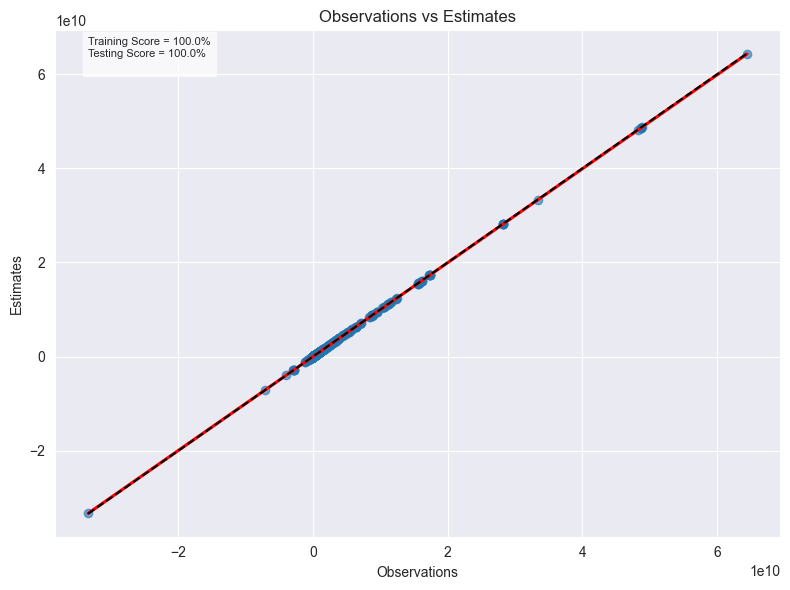

In [11]:
lasso.scatter_plot( X, y )

####  📊  Ridge

In [12]:
ridge = cs.Ridge( )
X = data.values
y = ds.targets
ridge.train( X, y )
ridge.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.440104,0.416667,0.000000,0.435417,0.0,0.0075,0.0
1,0.440104,0.416667,0.000000,0.435417,0.0,0.0075,0.0
2,0.440104,0.416667,0.000000,0.435417,0.0,0.0075,0.0
3,0.440104,0.416667,0.000000,0.435417,0.0,0.0075,0.0
4,0.440104,0.416667,0.000000,0.435417,0.0,0.0075,0.0
...,...,...,...,...,...,...,...
395,0.440104,0.416667,0.000000,0.435417,0.0,0.0075,0.0
396,0.440104,0.416667,0.000000,0.435417,0.0,0.0075,0.0
397,0.440104,0.416667,0.333333,0.435417,1.0,0.0075,0.5
398,0.440104,0.416667,0.000000,0.435417,0.0,0.0075,0.0


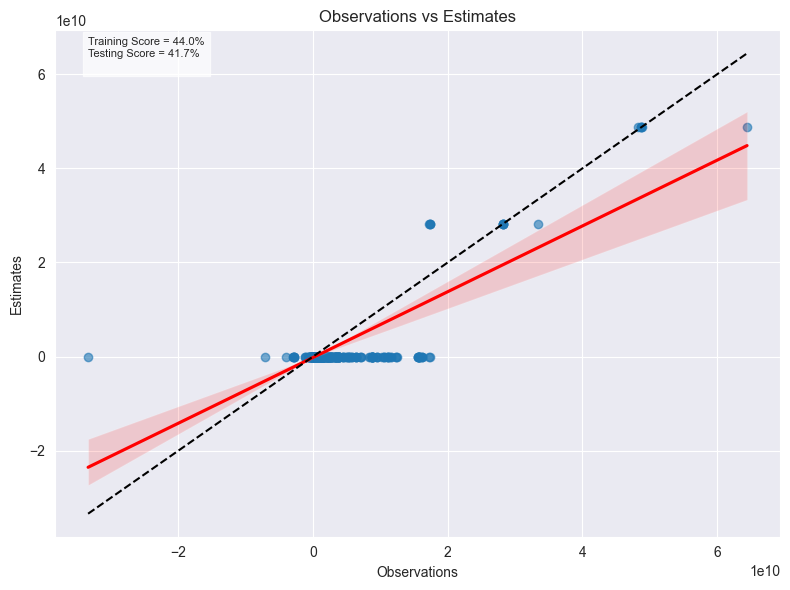

In [13]:
ridge.scatter_plot( X, y )

####  📉 Gradient Descent

In [13]:
gradient = cs.GradientDescent( )
X = data.values
y = ds.targets
gradient.train( X, y )
gradient.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.416146,0.39375,0.0,0.411667,0.0,0.00611,0.0
1,0.416146,0.39375,0.0,0.411667,0.0,0.00611,0.0
2,0.416146,0.39375,0.0,0.411667,0.0,0.00611,0.0
3,0.416146,0.39375,0.0,0.411667,0.0,0.00611,0.0
4,0.416146,0.39375,0.0,0.411667,0.0,0.00611,0.0
...,...,...,...,...,...,...,...
395,0.416146,0.39375,0.0,0.411667,0.0,0.00611,0.0
396,0.416146,0.39375,0.0,0.411667,0.0,0.00611,0.0
397,0.416146,0.39375,0.0,0.411667,0.0,0.00611,0.0
398,0.416146,0.39375,0.0,0.411667,0.0,0.00611,0.0


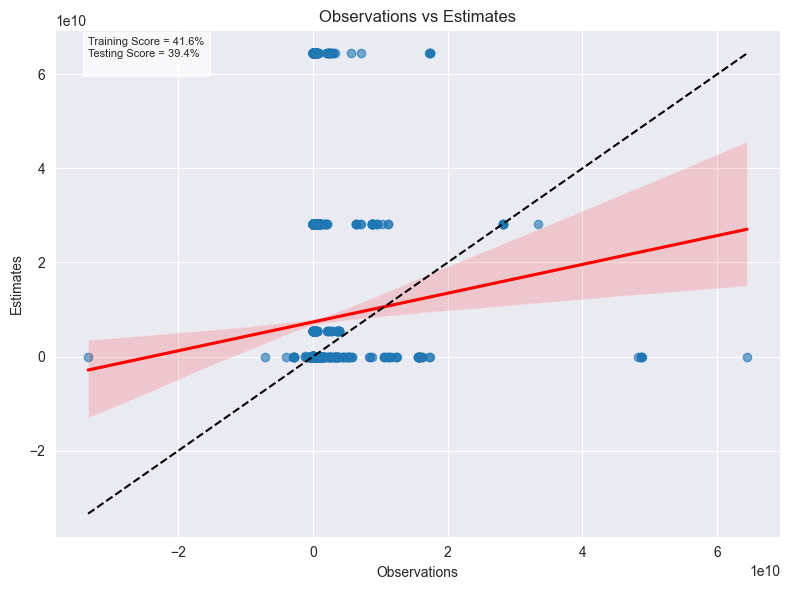

In [14]:
gradient.scatter_plot( X, y )

####  🎭 Nearest Neighbor

In [15]:
neighbors = cs.NearestNeighbor( )
X = data.values
y = ds.targets
neighbors.train( X, y )
neighbors.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.817708,0.81875,0.000000,0.817917,0.0,0.362726,0.0
1,0.817708,0.81875,0.000000,0.817917,0.0,0.362726,0.0
2,0.817708,0.81875,0.000000,0.817917,0.0,0.362726,0.0
3,0.817708,0.81875,0.000000,0.817917,0.0,0.362726,0.0
4,0.817708,0.81875,0.666667,0.817917,1.0,0.362726,0.8
...,...,...,...,...,...,...,...
395,0.817708,0.81875,0.000000,0.817917,0.0,0.362726,0.0
396,0.817708,0.81875,0.000000,0.817917,0.0,0.362726,0.0
397,0.817708,0.81875,0.333333,0.817917,1.0,0.362726,0.5
398,0.817708,0.81875,0.000000,0.817917,0.0,0.362726,0.0


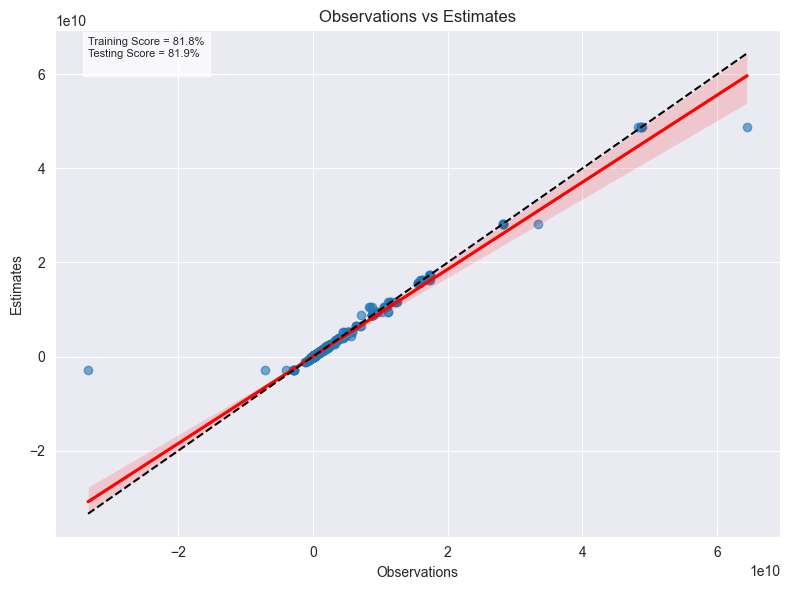

In [16]:
neighbors.scatter_plot( X, y )

#### 🔧 Adaptive Boost

In [17]:
adaptive = cs.AdaptiveBoost( )
X = data.values
y = ds.targets
adaptive.train( X, y )
adaptive.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.501042,0.483333,0.0,0.4975,0.0,0.035,0.000000
1,0.501042,0.483333,0.0,0.4975,0.0,0.035,0.000000
2,0.501042,0.483333,0.0,0.4975,0.0,0.035,0.000000
3,0.501042,0.483333,0.4,0.4975,1.0,0.035,0.571429
4,0.501042,0.483333,0.5,0.4975,1.0,0.035,0.666667
...,...,...,...,...,...,...,...
395,0.501042,0.483333,0.0,0.4975,0.0,0.035,0.000000
396,0.501042,0.483333,0.0,0.4975,0.0,0.035,0.000000
397,0.501042,0.483333,0.0,0.4975,0.0,0.035,0.000000
398,0.501042,0.483333,1.0,0.4975,1.0,0.035,1.000000


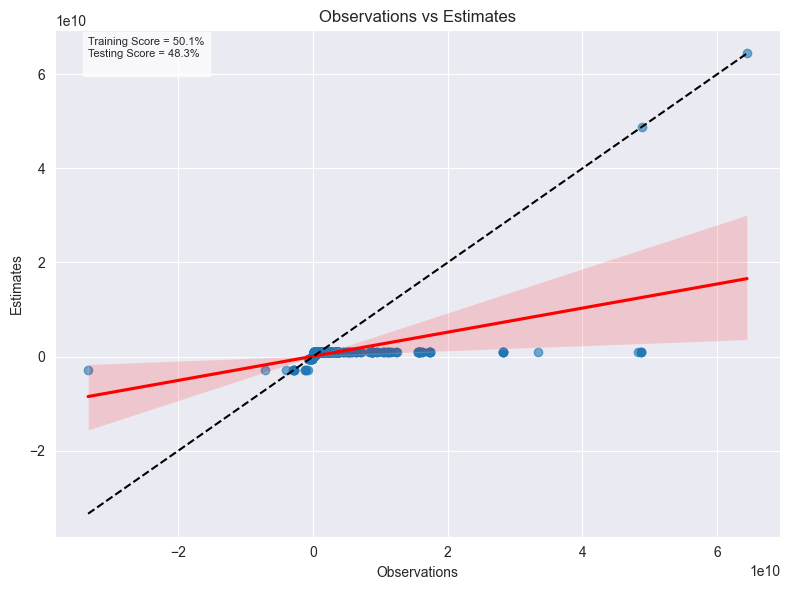

In [18]:
adaptive.scatter_plot( X, y )

#### 🗃️ Bagging Model

In [19]:
bagging = cs.BaggingModel( )
X = data.values
y = ds.targets
bagging.train( X, y )
bagging.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.995313,0.997917,1.0,0.995833,1.0,0.975,1.0
1,0.995313,0.997917,1.0,0.995833,1.0,0.975,1.0
2,0.995313,0.997917,1.0,0.995833,1.0,0.975,1.0
3,0.995313,0.997917,1.0,0.995833,1.0,0.975,1.0
4,0.995313,0.997917,1.0,0.995833,1.0,0.975,1.0
...,...,...,...,...,...,...,...
395,0.995313,0.997917,1.0,0.995833,1.0,0.975,1.0
396,0.995313,0.997917,1.0,0.995833,1.0,0.975,1.0
397,0.995313,0.997917,1.0,0.995833,1.0,0.975,1.0
398,0.995313,0.997917,1.0,0.995833,1.0,0.975,1.0


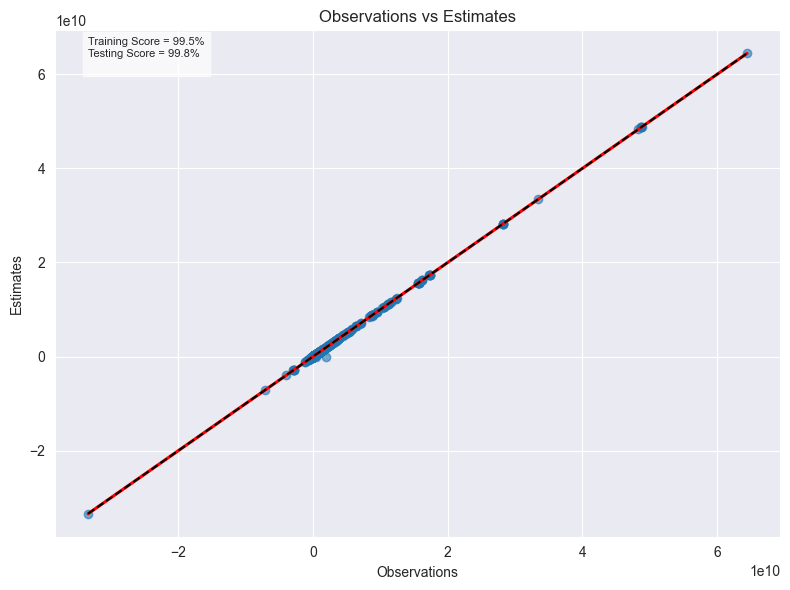

In [20]:
bagging.scatter_plot( X, y )

#### ✨ Support Vector Machine

In [21]:
support = cs.SupportVector( )
X = data.values
y = ds.targets
support.train( X, y )
support.score( X, y )

,Training Score,Testing Score,Precision Score,Accuracy Score,Recall Score,Balanced Accuracy,F Score
0,0.466667,0.445833,1.000000,0.4625,1.0,0.05381,1.000000
1,0.466667,0.445833,1.000000,0.4625,1.0,0.05381,1.000000
2,0.466667,0.445833,0.000000,0.4625,0.0,0.05381,0.000000
3,0.466667,0.445833,0.000000,0.4625,0.0,0.05381,0.000000
4,0.466667,0.445833,0.571429,0.4625,1.0,0.05381,0.727273
...,...,...,...,...,...,...,...
395,0.466667,0.445833,0.000000,0.4625,0.0,0.05381,0.000000
396,0.466667,0.445833,0.000000,0.4625,0.0,0.05381,0.000000
397,0.466667,0.445833,0.400000,0.4625,1.0,0.05381,0.571429
398,0.466667,0.445833,0.000000,0.4625,0.0,0.05381,0.000000


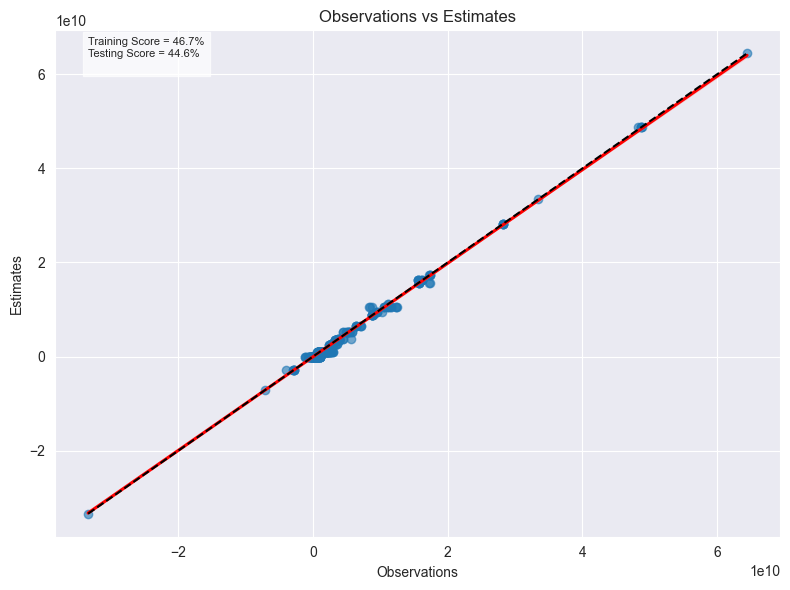

In [22]:
support.scatter_plot( X, y )

# Regression Models


In [7]:
import regressions as rs
reload( rs )

<module 'regressions' from 'C:\\Users\\terry\\source\\repos\\Mathy\\regressions.py'>

#### 📦 Least Squares

In [8]:
ls_regressor = rs.LeastSquares( )
X = data.values
y = ds.targets
ls_regressor.train( X, y )
ls_regressor.score( X, y )

,Training Score,Testing Score,R Squared Score,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error,Max Error,Explained Variance Score
0,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
1,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
2,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
3,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
4,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
5,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
6,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0
7,1.0,1.0,1.0,2.565653e-07,5.677584e-13,0.0,0.000015,1.0


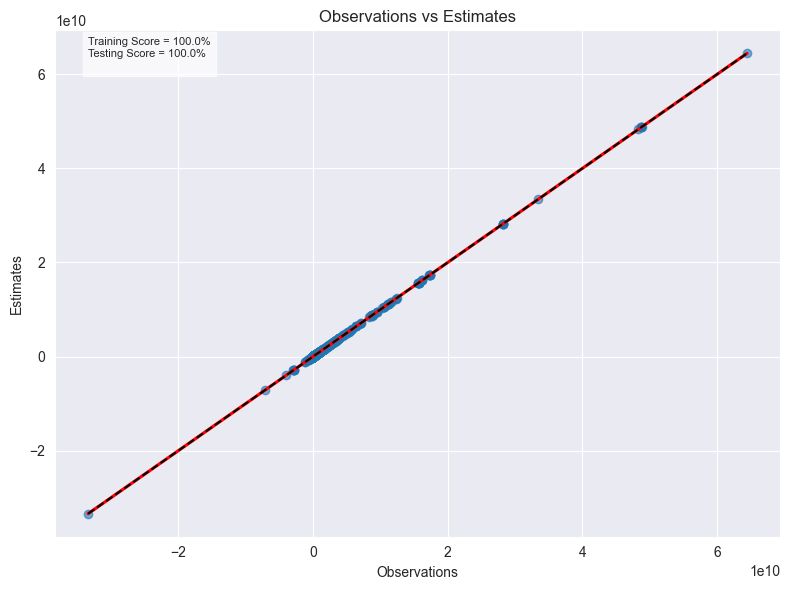

In [9]:
ls_regressor.scatter_plot( X, y )

#### 🔧 Ridge

In [ ]:
ridge_regressor = rs.Ridge( )
X = data.values
y = ds.targets
ridge_regressor.train( X, y )
ridge_regressor.score( X, y )

In [ ]:
ridge_regressor.scatter_plot( X, y )

#### ⚙️ LASSO

In [ ]:
lasso_regressor = rs.Lasso( )
X = data.values
y = ds.targets
lasso_regressor.train( X, y )
lasso_regressor.score( X, y )

In [ ]:
lasso_regressor.scatter_plot( X, y )

#### 🧪 Elastic Net

In [ ]:
elastic_regressor = rs.ElasticNet( )
X = data.values
y = ds.targets
elastic_regressor.train( X, y )
elastic_regressor.score( X, y )

In [ ]:
elastic_regressor.scatter_plot( X, y )

#### 📉 Gradient Descent

In [ ]:
sgd_regressor = rs.GradientDescent( )
X = data.values
y = ds.targets
sgd_regressor.train( X, y )
sgd_regressor.score( X, y )

In [ ]:
sgd_regressor.scatter_plot( X, y )

#### 🎭 Nearest Neighbor

In [ ]:
knn_regressor = rs.NearestNeighbor( )
X = data.values
y = ds.targets
knn_regressor.train( X, y )
knn_regressor.score( X, y )

In [ ]:
knn_regressor.scatter_plot( X, y )

#### 🚀 Gradient Boost

In [ ]:
gb_regressor = rs.GradientBoost( )
X = data.values
y = ds.targets
gb_regressor.train( X, y )
gb_regressor.score( X, y )

In [ ]:
gb_regressor.scatter_plot( X, y )

#### 🎨 Adaptive Boost

In [ ]:
adaptive_regressor = rs.AdaptiveBoost( )
X = data.values
y = ds.targets
adaptive_regressor.train( X, y )
adaptive_regressor.score( X, y )

In [ ]:
adaptive_regressor.scatter_plot( X, y )

#### 📁 Least Angle

In [ ]:
angle_regressor = rs.LeastAngle( )
X = data.values
y = ds.targets
angle_regressor.train( X, y )
angle_regressor.score( X, y )

In [ ]:
angle_regressor.scatter_plot( X, y )

#### 🔬 Bayesian

In [ ]:
bayesian_regressor = rs.Bayesian( )
X = data.values
y = ds.targets
bayesian_regressor.train( X, y )
bayesian_regressor.score( X, y )

In [ ]:
bayesian_regressor.scatter_plot( X, y )

#### ✨ Gaussian Process

In [ ]:
gaussian_regressor = rs.GaussianProcess( )
X = data.values
y = ds.targets
gaussian_regressor.train( X, y )
gaussian_regressor.score( X, y )

In [ ]:
gaussian_regressor.scatter_plot( X, y )

#### 🚀 Support Vector Machine

In [ ]:
svm_regressor = rs.SupportVector( )
X = data.values
y = ds.targets
svm_regressor.train( X, y )
svm_regressor.score( X, y )

In [ ]:
svm_regressor.scatter_plot( X, y )